In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
tonygordonjr_spotify_dataset_2023_path = kagglehub.dataset_download('tonygordonjr/spotify-dataset-2023')
print('Data source import complete.')
path = r'/kaggle/input/spotify-dataset-2023/spotify_data_12_20_2023.csv'
songs = pd.read_csv(path, low_memory=False)



Using Colab cache for faster access to the 'spotify-dataset-2023' dataset.
Data source import complete.


In [3]:
numeric_features = [
    'acousticness', 'danceability', 'energy', 'instrumentalness',
    'liveness', 'speechiness', 'valence', 'tempo', 'loudness', 'duration_ms'
]
categorical_features = [
    'key', 'mode', 'time_signature',
    'genre_0', 'genre_1', 'genre_2', 'genre_3'
]


df = songs[numeric_features + categorical_features].copy()
df = df.dropna(subset=['genre_0'])
print(f"Dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")


Dataset: 209,863 rows, 17 columns


In [4]:
df.genre_0.value_counts()

,count
genre_0,
karaoke,15344
dance pop,4496
classical,3848
album rock,3707
baroque,3421
...,...
jovem guarda,1
cornwall indie,1
australian reggae fusion,1


In [5]:
mask = df.dtypes == float
float_cols = df.columns[mask]
# define a limit above which we will log transform
skew_limit = 0.75
skew_vals = df[float_cols].skew()
skew_cols = (skew_vals
             .sort_values(ascending=False)
             .to_frame()
             .rename(columns={0:'Skew'})
             .query('abs(Skew) > {}'.format(skew_limit)))

skew_cols

,Skew
duration_ms,9.803751
speechiness,3.449941
liveness,2.245896
instrumentalness,1.013256
loudness,-1.484269
time_signature,-3.322107


In [6]:
print("=== NA ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct})
print(missing_df[missing_df['count'] > 0].to_string())

print(f"\n=== Duplicates ===")
print(f"Duplicates on all columns: {df.duplicated().sum():,}")
print(f"Duplicates on numerical features: {df[numeric_features].duplicated().sum():,}")

desc = df[numeric_features].describe().T[['min', 'max', 'mean', 'std']]

expected = {
    'acousticness':    (0, 1),
    'danceability':    (0, 1),
    'energy':          (0, 1),
    'instrumentalness':(0, 1),
    'liveness':        (0, 1),
    'speechiness':     (0, 1),
    'valence':         (0, 1),
    'tempo':           (0, 250),
    'loudness':        (-60, 0),
    'duration_ms':     (0, 3_600_000),
}

desc['expected_min'] = [expected[f][0] for f in numeric_features]
desc['expected_max'] = [expected[f][1] for f in numeric_features]
desc['out_of_range'] = (
    (df[numeric_features].min() < desc['expected_min']) |
    (df[numeric_features].max() > desc['expected_max'])
)
print(desc.to_string())


=== NA ===
                   count    pct
acousticness         489   0.23
danceability         489   0.23
energy               489   0.23
instrumentalness     489   0.23
liveness             489   0.23
speechiness          489   0.23
valence              489   0.23
tempo                489   0.23
loudness             489   0.23
duration_ms          489   0.23
key                  489   0.23
mode                 489   0.23
time_signature       489   0.23
genre_1            90377  43.06
genre_2           132644  63.21
genre_3           161253  76.84

=== Duplicates ===
Duplicates on all columns: 10,116
Duplicates on numerical features: 11,445
                     min          max           mean            std  expected_min  expected_max  out_of_range
acousticness         0.0        0.996       0.390691       0.367554             0             1         False
danceability         0.0        0.988       0.559184       0.193326             0             1         False
energy              

=== Top 20 genres (genre_0) ===
genre_0
karaoke                 0.073114
dance pop               0.021424
classical               0.018336
album rock              0.017664
baroque                 0.016301
atl hip hop             0.015901
pop                     0.013356
hip hop                 0.011560
k-pop                   0.011188
big room                0.010631
adult standards         0.010130
alternative metal       0.009764
workout product         0.009716
arkansas country        0.009540
sleep                   0.008958
piano cover             0.008906
contemporary country    0.008567
r&b                     0.008039
g funk                  0.007700
classic country pop     0.007076

Top 3 genres cover: 11.3% of dataset
Number of unique genres: 3008


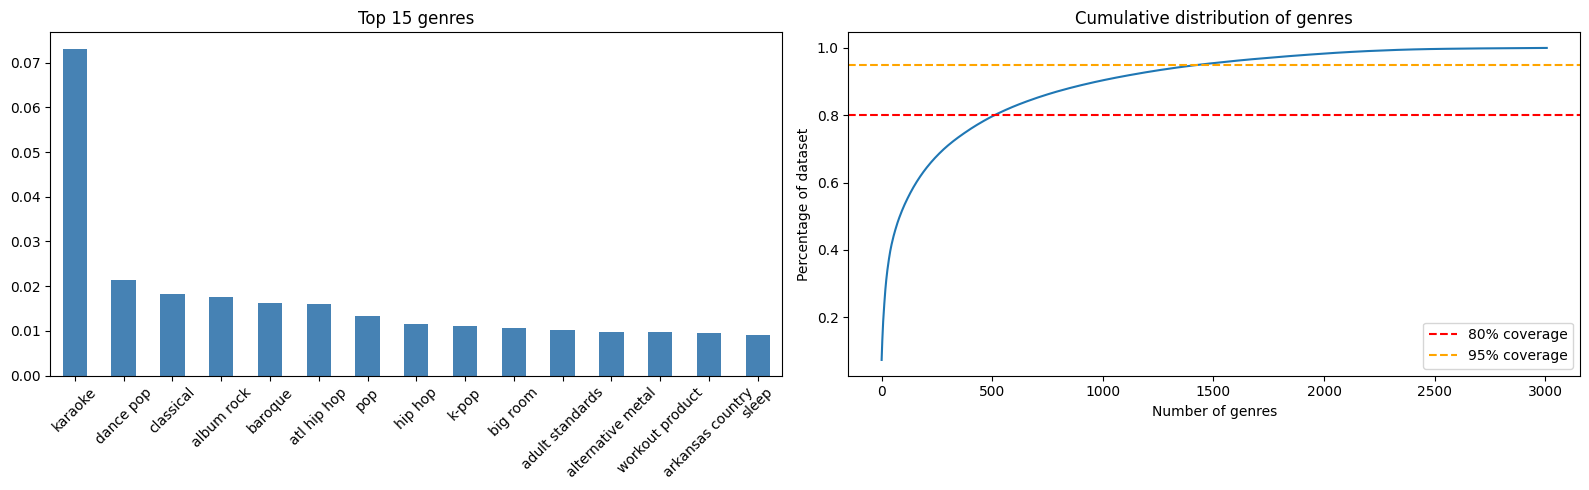

In [7]:

print("=== Top 20 genres (genre_0) ===")
genre_counts = df['genre_0'].value_counts(normalize=True)
print(genre_counts.head(20).to_string())
print(f"\nTop 3 genres cover: {genre_counts.head(3).sum()*100:.1f}% of dataset")
print(f"Number of unique genres: {df['genre_0'].nunique()}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

genre_counts.head(15).plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 genres')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

cumsum = genre_counts.cumsum()
axes[1].plot(range(len(cumsum)), cumsum.values)
axes[1].axhline(0.8, color='red', linestyle='--', label='80% coverage')
axes[1].axhline(0.95, color='orange', linestyle='--', label='95% coverage')
axes[1].set_title('Cumulative distribution of genres')
axes[1].set_xlabel('Number of genres')
axes[1].set_ylabel('Percentage of dataset')
axes[1].legend()

plt.tight_layout()
plt.show()

In [8]:
n_for_80 = (cumsum < 0.8).sum() + 1
print(f"\n{'='*40}")
print(f"{n_for_80} genres needed to cover 80% of dataset")


from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder

X = df[numeric_features].fillna(df[numeric_features].median()).values
y = df['genre_0'].fillna('unknown').values

sample_idx = np.random.choice(len(df), size=20_000, replace=False)
X = df[numeric_features].fillna(df[numeric_features].median()).values[sample_idx]
y = df['genre_0'].fillna('unknown').values[sample_idx]

le = LabelEncoder()
y_enc = le.fit_transform(y)

scores = cross_val_score(
    RandomForestClassifier(
        n_estimators=30,
        max_depth=8,
        random_state=42,
        n_jobs=1
    ),
    X, y_enc, cv=3, scoring='accuracy'
)
scores = cross_val_score(
    RandomForestClassifier(n_estimators=30, random_state=42, n_jobs=-1),
    X, y_enc, cv=3, scoring='accuracy'
)

acc = scores.mean()


511 genres needed to cover 80% of dataset


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


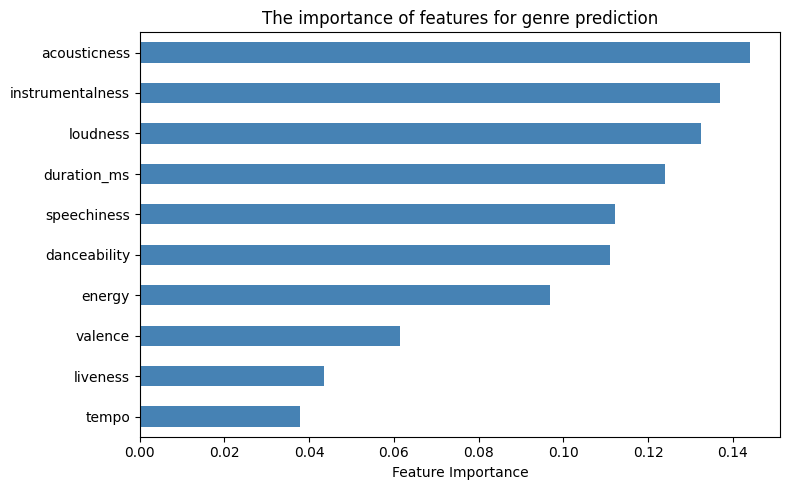

In [9]:
rf = RandomForestClassifier(n_estimators=30, random_state=42, max_depth = 8, n_jobs=-1)
rf.fit(X, y_enc)

importances = pd.Series(rf.feature_importances_, index=numeric_features).sort_values(ascending=True)
plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue')
plt.title('The importance of features for genre prediction')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()


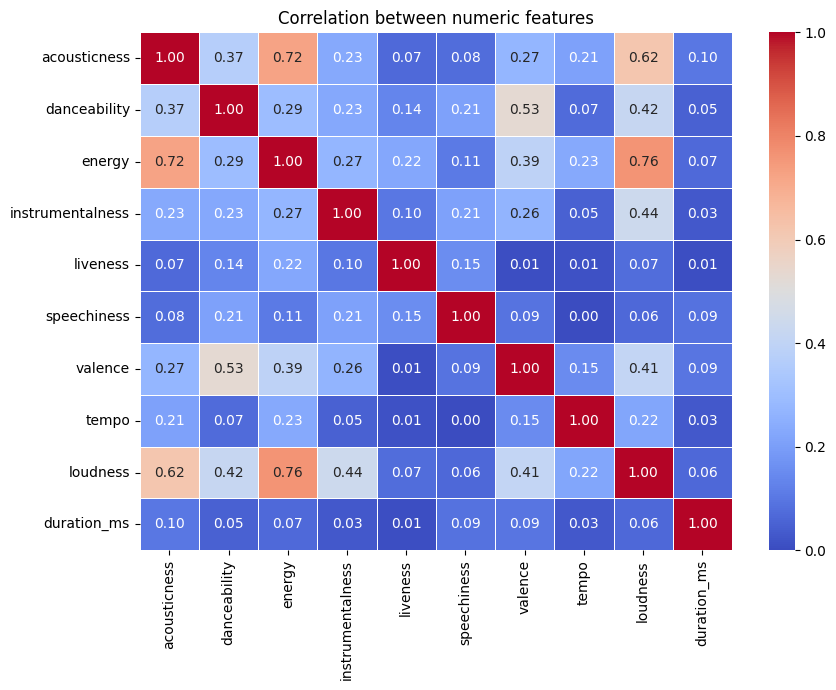

=== Pairs with correlation > 0.7 ===
  energy               ↔ loudness              r=0.763
  acousticness         ↔ energy                r=0.723


In [10]:
corr = df[numeric_features].corr().abs()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f",
            linewidths=0.5, vmin=0, vmax=1)
plt.title("Correlation between numeric features")
plt.tight_layout()
plt.show()
print("=== Pairs with correlation > 0.7 ===")
high_corr_pairs = []
for i in range(len(numeric_features)):
    for j in range(i+1, len(numeric_features)):
        c = corr.iloc[i, j]
        if c > 0.7:
            high_corr_pairs.append((numeric_features[i], numeric_features[j], round(c, 3)))

if high_corr_pairs:
    for f1, f2, c in sorted(high_corr_pairs, key=lambda x: -x[2]):
        print(f"  {f1:20} ↔ {f2:20}  r={c}")
else:
    print("No pairs with correlation > 0.7 — features are sufficiently independent")


In [11]:
# Effective number of features through PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(
    df[numeric_features].fillna(df[numeric_features].median())
)
pca = PCA().fit(X_scaled)
explained = np.cumsum(pca.explained_variance_ratio_)
n_components_90 = np.argmax(explained >= 0.90) + 1
n_components_95 = np.argmax(explained >= 0.95) + 1

print(f"\nEffective data dimension:")
print(f"  90% variance explained {n_components_90} out of {len(numeric_features)}")
print(f"  95% variance explained {n_components_95} out of {len(numeric_features)}")



Effective data dimension:
  90% variance explained 7 out of 10
  95% variance explained 8 out of 10


In [15]:

from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(
    df[numeric_features].fillna(df[numeric_features].median())
)

knn = NearestNeighbors(n_neighbors=11, metric='cosine')
knn.fit(X_scaled)

np.random.seed(42)
test_indices = np.random.randint(0, len(df), 5)

print("=== KNN Baseline (cosine similarity on raw features) ===\n")
genre_match_rates = []

for idx in test_indices:
    distances, indices = knn.kneighbors([X_scaled[idx]])
    neighbors = indices[0][1:]

    query_genre = df.iloc[idx]['genre_0']
    neighbor_genres = df.iloc[neighbors]['genre_0'].values
    match_rate = (neighbor_genres == query_genre).mean()
    genre_match_rates.append(match_rate)

    print(f"Track #{idx} | genre: {query_genre}")
    print(f"  energy={df.iloc[idx]['energy']:.2f}  tempo={df.iloc[idx]['tempo']:.0f}  valence={df.iloc[idx]['valence']:.2f}")
    print(f"  Top-10 neighbors: {list(neighbor_genres)}")
    print(f"  Genre match: {match_rate*100:.0f}%\n")

avg_match = np.mean(genre_match_rates)
print(f"{'='*40}")
print(f"Average genre match in top 10: {avg_match*100:.1f}%")
if avg_match > 0.7:
    print("good")
elif avg_match > 0.4:
    print("avg")
else:
    print("bad")


=== KNN Baseline (cosine similarity on raw features) ===

Track #121958 | genre: ghanaian hip hop
  energy=0.64  tempo=105  valence=0.19
  Top-10 neighbors: ['baton rouge rap', 'hip hop', 'hip hop', 'hip hop', 'italo dance', 'canadian hip hop', 'hip hop', 'k-pop girl group', 'atl hip hop', 'hip hop']
  Genre match: 0%

Track #146867 | genre: alternative hip hop
  energy=0.62  tempo=66  valence=0.69
  Top-10 neighbors: ['reggaeton flow', 'hip hop', 'atl hip hop', 'queens hip hop', 'hip hop', 'dirty south rap', 'atl hip hop', 'hip hop', 'atl hip hop', 'philly rap']
  Genre match: 0%

Track #131932 | genre: musica para ninos
  energy=0.20  tempo=78  valence=0.33
  Top-10 neighbors: ['musica para ninos', 'musica para ninos', 'sleep', 'bebop', 'sleep', 'metis fiddle', 'bebop', 'sleep', 'karaoke', 'karaoke']
  Genre match: 20%

Track #103694 | genre: sleep
  energy=0.00  tempo=0  valence=0.00
  Top-10 neighbors: ['sleep', 'sleep', 'sleep', 'brain waves', 'sleep', 'brain waves', 'sleep', 'sle